In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
sonalshinde123_student_academic_performance_dataset_path = kagglehub.dataset_download('sonalshinde123/student-academic-performance-dataset')

print('Data source import complete.')


100%|██████████| 14.6k/14.6k [00:00<00:00, 21.9MB/s]

Extracting files...
Data source import complete.


In [ ]:
!pip install -U kagglehub

## **Data Preprocessing and EDA **

In [ ]:
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download("sonalshinde123/student-academic-performance-dataset")

print("Dataset downloaded at:", path)

print("Files:", os.listdir(path))

df = pd.read_csv(path + "/Final_Marks_Data.csv")

df.head()

Using Colab cache for faster access to the 'student-academic-performance-dataset' dataset.
Dataset downloaded at: /kaggle/input/student-academic-performance-dataset
Files: ['.nfs0000000088a0a809000000b3', 'Final_Marks_Data.csv']


,Student_ID,Attendance (%),Internal Test 1 (out of 40),Internal Test 2 (out of 40),Assignment Score (out of 10),Daily Study Hours,Final Exam Marks (out of 100)
0,S1000,84,30,36,7,3,72
1,S1001,91,24,38,6,3,56
2,S1002,73,29,26,7,3,56
3,S1003,80,36,35,7,3,74
4,S1004,84,31,37,8,3,66


In [ ]:
df.describe()

,Attendance (%),Internal Test 1 (out of 40),Internal Test 2 (out of 40),Assignment Score (out of 10),Daily Study Hours,Final Exam Marks (out of 100)
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,84.891500,32.115500,32.464500,7.507000,2.823500,64.855000
std,7.758855,4.563504,4.522827,1.021015,0.608714,11.341265
min,52.000000,18.000000,16.000000,4.000000,1.000000,25.000000
25%,80.000000,29.000000,29.000000,7.000000,2.000000,58.000000
50%,85.000000,32.000000,33.000000,8.000000,3.000000,65.000000
75%,90.000000,35.000000,36.000000,8.000000,3.000000,73.000000
max,100.000000,40.000000,40.000000,10.000000,5.000000,100.000000


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import matplotlib.pyplot as plt

In [ ]:
df.rename(columns={"Internal Test 2 (out of 40)": "lab assessment"}, inplace=True)
print("Columns in dataset:\n", df.columns)

Columns in dataset:
 Index(['Student_ID', 'Attendance (%)', 'Internal Test 1 (out of 40)',
       'lab assessment', 'Assignment Score (out of 10)', 'Daily Study Hours',
       'Final Exam Marks (out of 100)'],
      dtype='object')


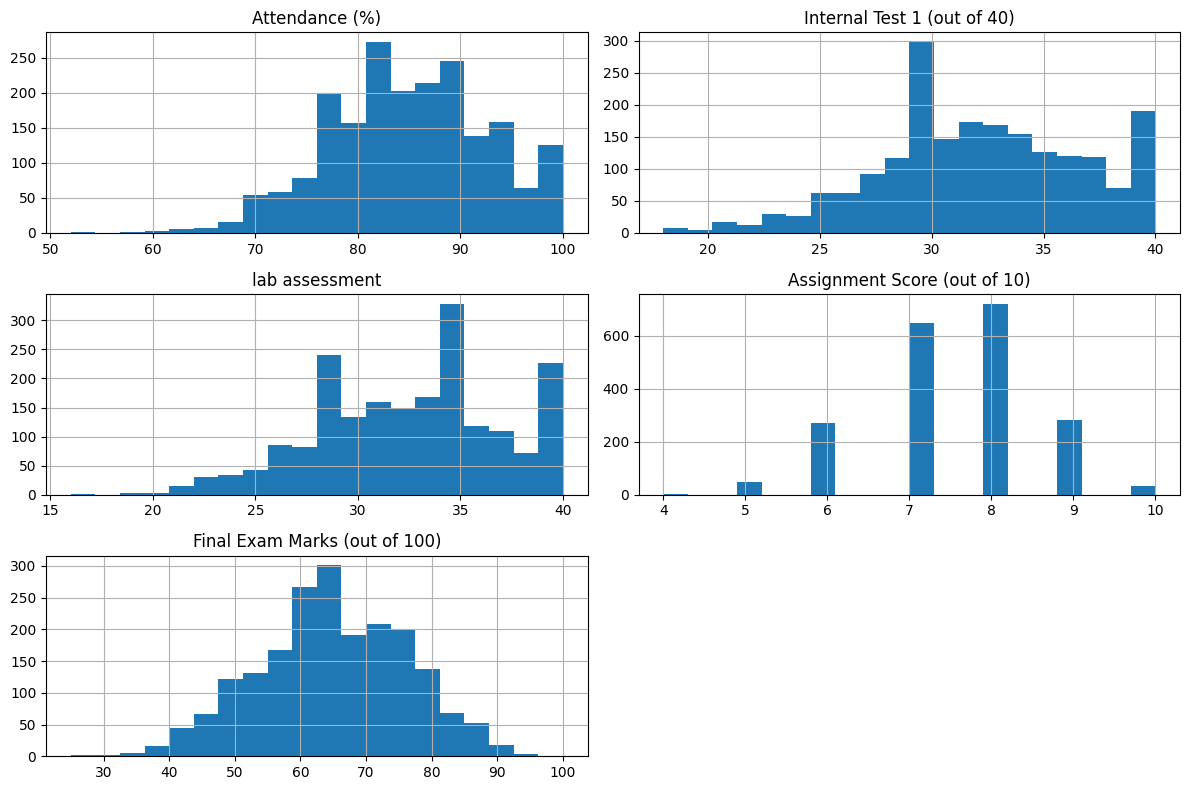

In [ ]:
import matplotlib.pyplot as plt

cols = ['Attendance (%)','Internal Test 1 (out of 40)','lab assessment','Assignment Score (out of 10)','Final Exam Marks (out of 100)']

df[cols].hist(figsize=(12,8), bins=20)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np

cols = [
    'Attendance (%)',
    'Internal Test 1 (out of 40)',
    'lab assessment',
    'Assignment Score (out of 10)',
    'Final Exam Marks (out of 100)'
]

for col in cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print("Feature:", col)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Number of Outliers:", len(outliers))
    print("------------------------------------")

Feature: Attendance (%)
Q1: 80.0
Q3: 90.0
IQR: 10.0
Lower Bound: 65.0
Upper Bound: 105.0
Number of Outliers: 10
------------------------------------
Feature: Internal Test 1 (out of 40)
Q1: 29.0
Q3: 35.0
IQR: 6.0
Lower Bound: 20.0
Upper Bound: 44.0
Number of Outliers: 8
------------------------------------
Feature: lab assessment
Q1: 29.0
Q3: 36.0
IQR: 7.0
Lower Bound: 18.5
Upper Bound: 46.5
Number of Outliers: 1
------------------------------------
Feature: Assignment Score (out of 10)
Q1: 7.0
Q3: 8.0
IQR: 1.0
Lower Bound: 5.5
Upper Bound: 9.5
Number of Outliers: 79
------------------------------------
Feature: Final Exam Marks (out of 100)
Q1: 58.0
Q3: 73.0
IQR: 15.0
Lower Bound: 35.5
Upper Bound: 95.5
Number of Outliers: 7
------------------------------------


In [ ]:
for col in cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"\nOutliers in {col}:")
    print(outliers[[col]].head())


Outliers in Attendance (%):
      Attendance (%)
678               60
712               60
754               63
852               62
1220              60

Outliers in Internal Test 1 (out of 40):
     Internal Test 1 (out of 40)
118                           18
533                           19
576                           18
924                           19
960                           18

Outliers in lab assessment:
     lab assessment
678              16

Outliers in Assignment Score (out of 10):
     Assignment Score (out of 10)
39                             10
67                             10
118                             5
151                            10
165                             5

Outliers in Final Exam Marks (out of 100):
      Final Exam Marks (out of 100)
118                              35
678                              31
1007                            100
1194                             26
1205                             32


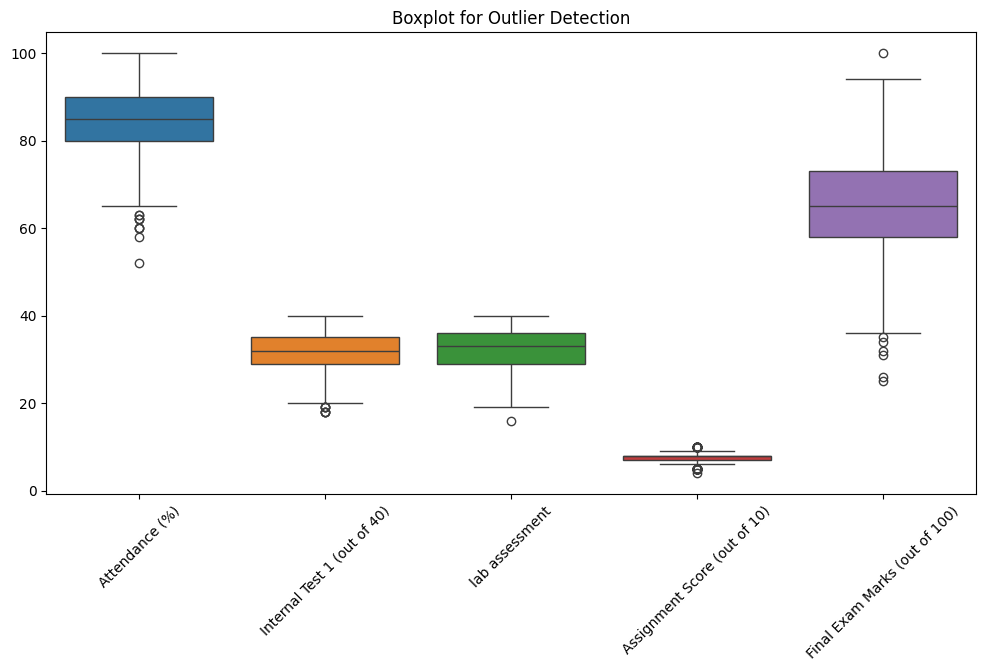

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.boxplot(data=df[cols])
plt.xticks(rotation=45)
plt.title("Boxplot for Outlier Detection")
plt.show()

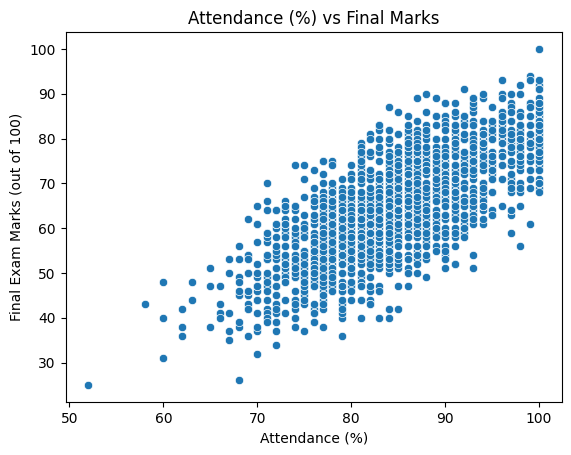

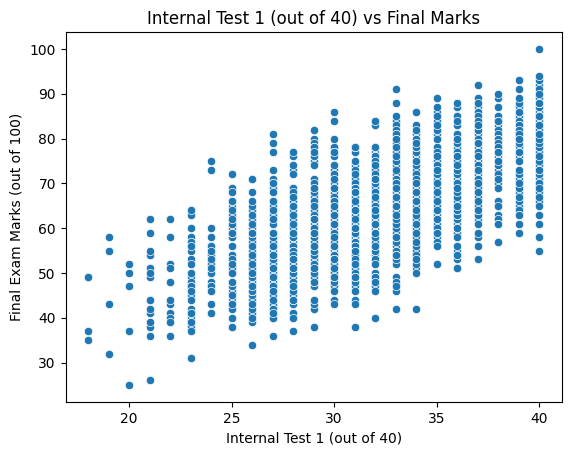

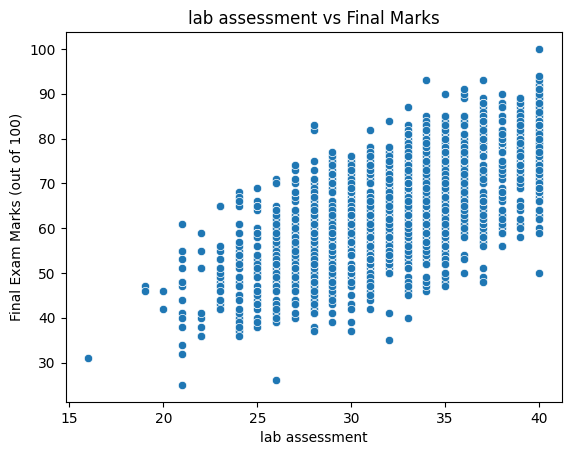

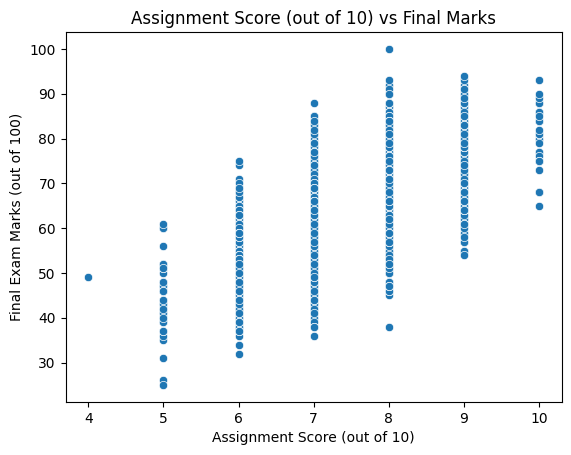

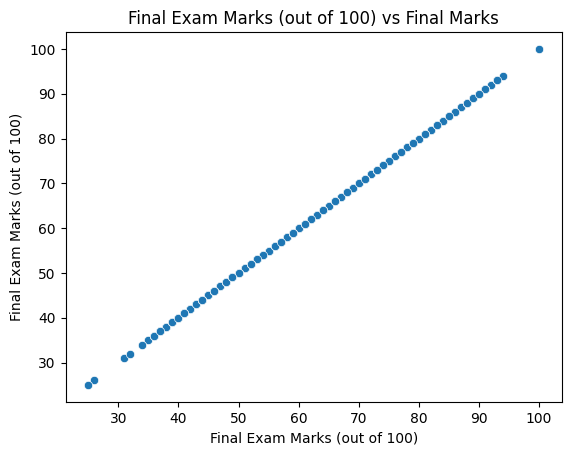

In [ ]:
features = ['Attendance (%)','Internal Test 1 (out of 40)','lab assessment','Assignment Score (out of 10)','Final Exam Marks (out of 100)']
target = 'Final Exam Marks (out of 100)'

for col in features:
    plt.figure()
    sns.scatterplot(x=df[col], y=df[target])
    plt.title(f"{col} vs Final Marks")
    plt.show()

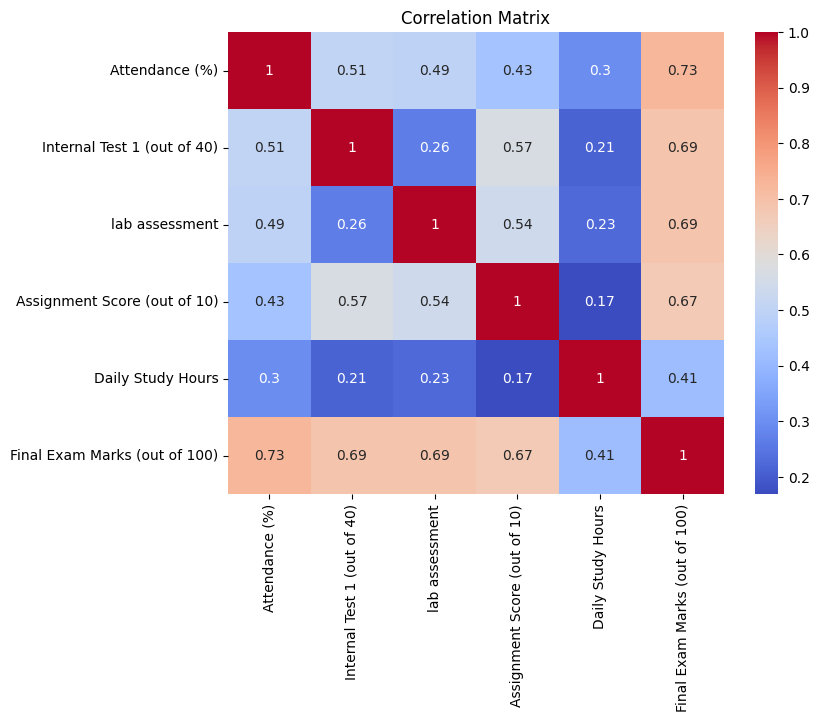

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

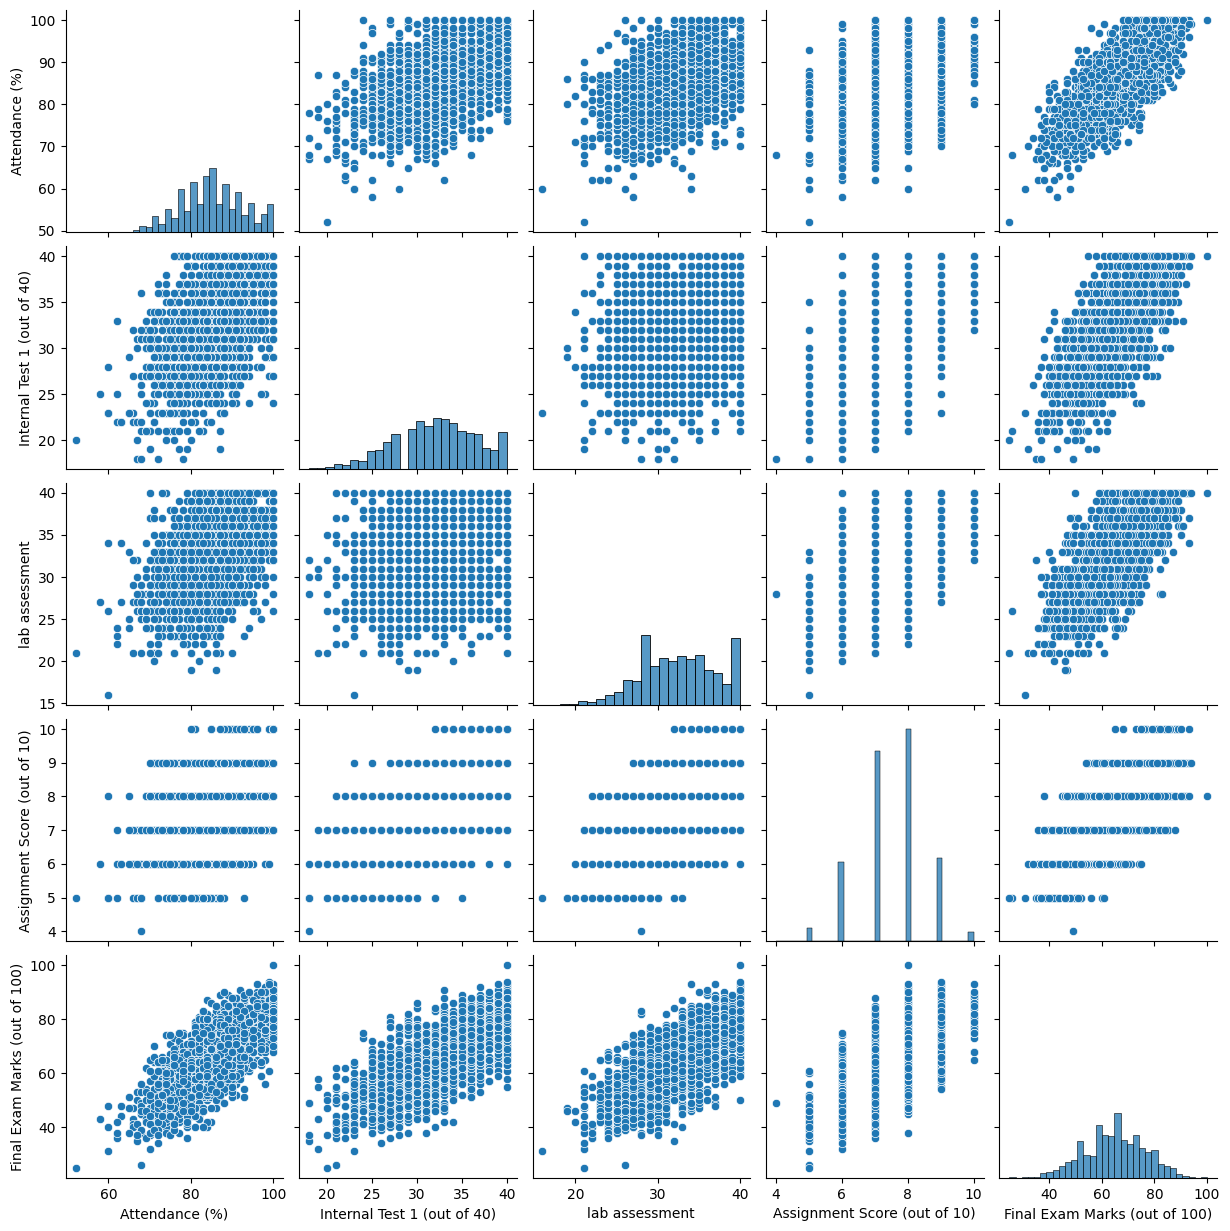

In [ ]:
sns.pairplot(df[cols])
plt.show()

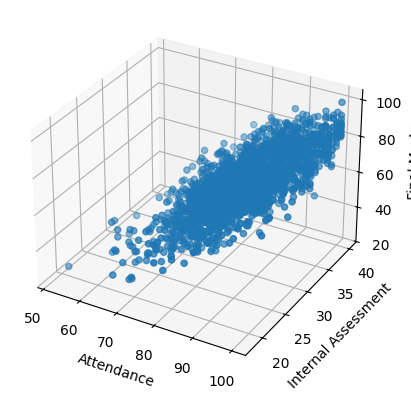

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df['Attendance (%)'],
           df['Internal Test 1 (out of 40)'],
           df['Final Exam Marks (out of 100)'])

ax.set_xlabel('Attendance')
ax.set_ylabel('Internal Assessment')
ax.set_zlabel('Final Marks')
plt.show()

In [ ]:
from scipy.stats import pearsonr

features = ['Attendance (%)','Internal Test 1 (out of 40)','lab assessment','Assignment Score (out of 10)','Final Exam Marks (out of 100)']

target = 'Final Exam Marks (out of 100)'

for col in features:
    corr, p = pearsonr(df[col], df[target])
    print(f"{col}")
    print(f"Correlation coefficient: {corr:.3f}")
    print(f"p-value: {p:.5f}")
    print("---------------------------")

Attendance (%)
Correlation coefficient: 0.726
p-value: 0.00000
---------------------------
Internal Test 1 (out of 40)
Correlation coefficient: 0.689
p-value: 0.00000
---------------------------
lab assessment
Correlation coefficient: 0.691
p-value: 0.00000
---------------------------
Assignment Score (out of 10)
Correlation coefficient: 0.669
p-value: 0.00000
---------------------------
Final Exam Marks (out of 100)
Correlation coefficient: 1.000
p-value: 0.00000
---------------------------


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

X = df[features]
y = df[target]

model = LinearRegression()
model.fit(X, y)
pred = model.predict(X)

rmse = np.sqrt(mean_squared_error(y, pred))
rae = np.sum(np.abs(pred - y)) / np.sum(np.abs(y - np.mean(y)))

print("Root Mean Square Error (RMSE):", rmse)
print("Relative Absolute Error (RAE):", rae)

Root Mean Square Error (RMSE): 8.572647311676216e-15
Relative Absolute Error (RAE): 6.213778455761471e-16


# **Model Building and Evaluation**


 LDA
Accuracy: 0.88
              precision    recall  f1-score   support

           0       0.86      0.72      0.79       122
           1       0.89      0.95      0.92       278

    accuracy                           0.88       400
   macro avg       0.87      0.84      0.85       400
weighted avg       0.88      0.88      0.88       400


 Logistic Regression
Accuracy: 0.88
              precision    recall  f1-score   support

           0       0.86      0.73      0.79       122
           1       0.89      0.95      0.92       278

    accuracy                           0.88       400
   macro avg       0.87      0.84      0.85       400
weighted avg       0.88      0.88      0.88       400


 Linear SVM
Accuracy: 0.88
              precision    recall  f1-score   support

           0       0.86      0.73      0.79       122
           1       0.89      0.95      0.92       278

    accuracy                           0.88       400
   macro avg       0.87      0.84      0.8

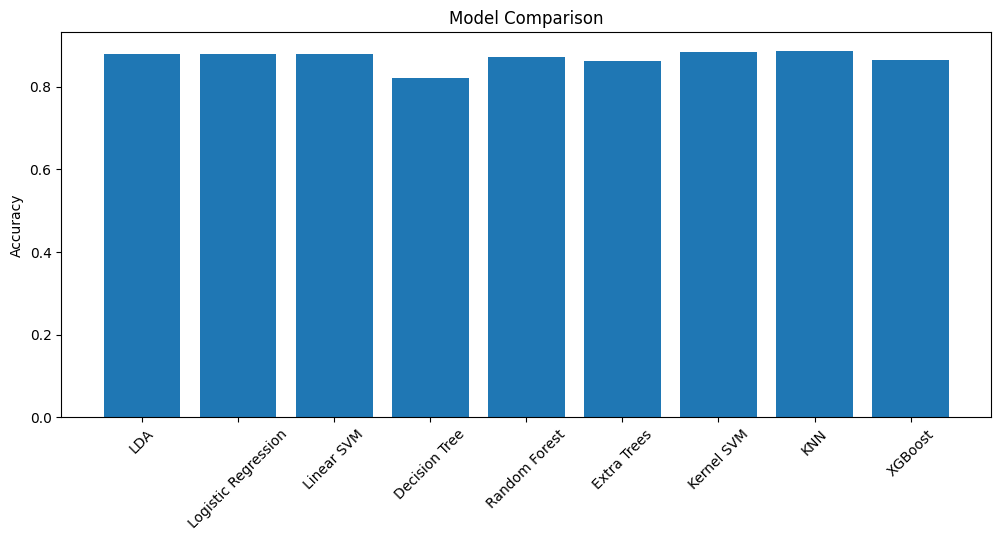

In [ ]:

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# Linear Models
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Tree-Based Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

# Other Non-Linear
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier



df['pass_fail'] = (df['Final Exam Marks (out of 100)'] >= 60).astype(int)

features = ['Attendance (%)','Internal Test 1 (out of 40)','lab assessment','Assignment Score (out of 10)']
X = df[features]
y = df['pass_fail']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



models = {

    # Linear Models
    "LDA": LinearDiscriminantAnalysis(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": SVC(kernel='linear'),

    # Tree-Based Models
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=200),
    "Extra Trees": ExtraTreesClassifier(n_estimators=200),

    # Other Non-Linear
    "Kernel SVM": SVC(kernel='rbf'),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "XGBoost": XGBClassifier(eval_metric='logloss')
}


results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"\n {name}")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))


import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.bar(results.keys(), results.values())
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()

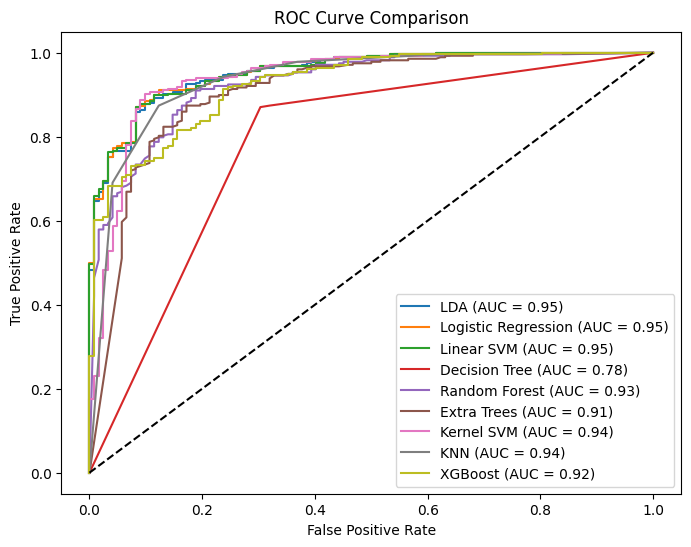

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for name, model in models.items():

    model.fit(X_train, y_train)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

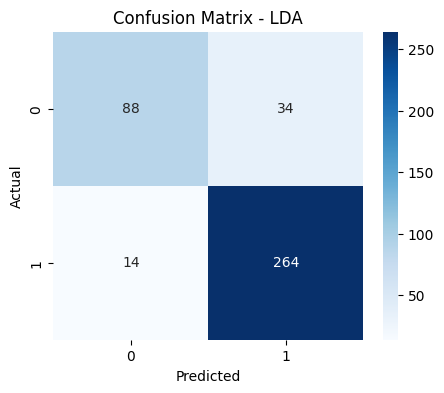

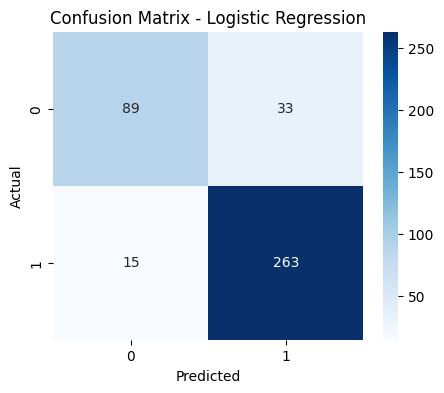

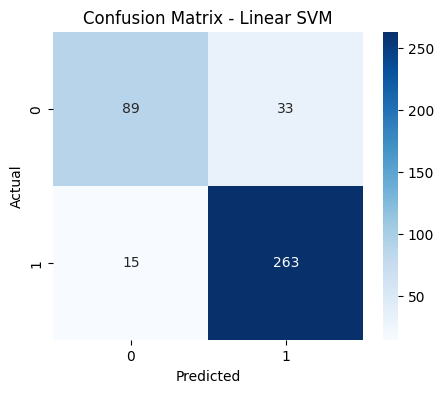

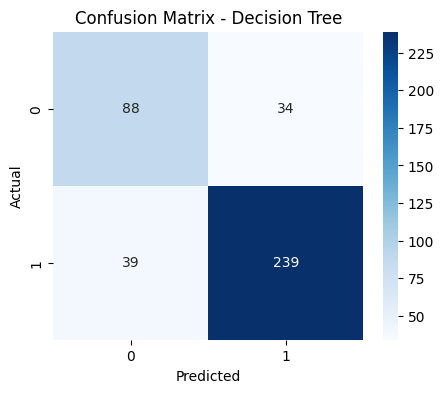

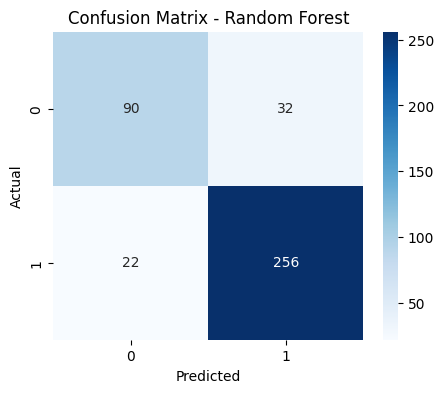

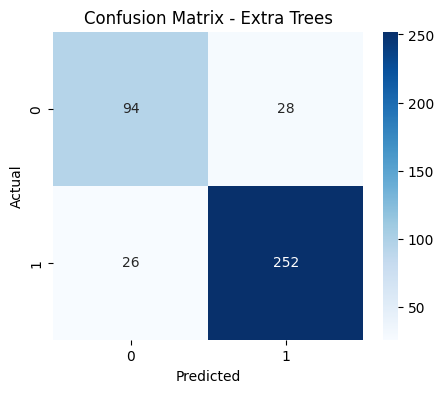

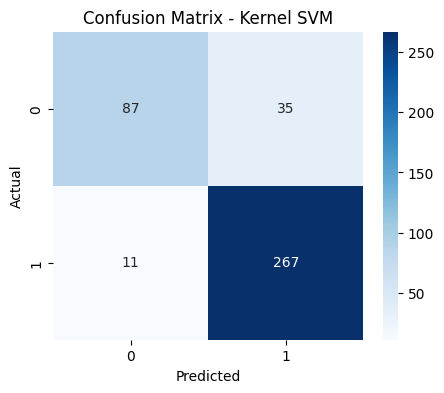

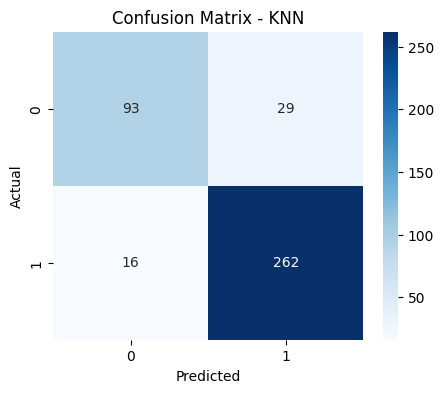

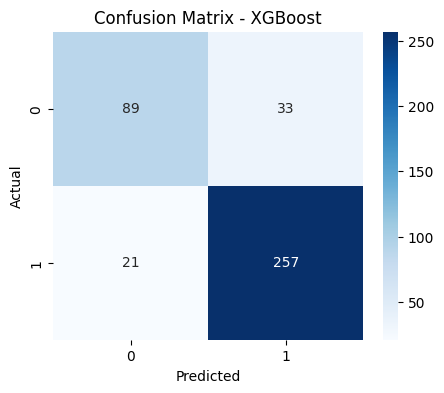

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

for name, model in models.items():

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [ ]:
import pickle

pickle.dump(model, open("model.pkl","wb"))
pickle.dump(scaler, open("scaler.pkl","wb"))

In [ ]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 61.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 92.1 MB/s eta 0:00:00


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import pickle
import plotly.graph_objects as go
import plotly.express as px

# Load model, scaler, and dataset
model = pickle.load(open("model.pkl","rb"))
scaler = pickle.load(open("scaler.pkl","rb"))
df = pd.read_csv("Final_Marks_Data.csv")

# Rename column to match model training features
if 'Internal Test 2 (out of 40)' in df.columns:
    df.rename(columns={'Internal Test 2 (out of 40)': 'lab assessment'}, inplace=True)

st.set_page_config(page_title="Student Performance AI", layout="wide")
st.title("Ġ Student Performance Prediction Dashboard")

st.sidebar.header("About")
st.sidebar.info("ML dashboard predicting student PASS/FAIL.")
st.sidebar.metric("Model Accuracy","88%")

st.header("ቄ Student ID Search")
student_id = st.text_input("Enter Student ID")

if st.button("Predict"):
    student = df[df['Student_ID']==student_id]
    if student.empty:
        st.error("Student ID not found")
    else:
        attendance = student['Attendance (%)'].values[0]
        internal = student['Internal Test 1 (out of 40)'].values[0]
        lab = student['lab assessment'].values[0]
        assignment = student['Assignment Score (out of 10)'].values[0]

        features_scaled = scaler.transform([[attendance, internal, lab, assignment]])
        pred = model.predict(features_scaled)[0]
        prob = model.predict_proba(features_scaled)[0][1]

        c1,c2,c3,c4 = st.columns(4)
        c1.metric("Attendance",f"{attendance}%")
        c2.metric("Internal Marks",internal)
        c3.metric("Lab",lab)
        c4.metric("Assignment",assignment)

        if pred==1: st.success("Likely to PASS")
        else: st.error("Likely to FAIL")

        fig = go.Figure(go.Indicator(mode="gauge+number", value=prob*100,
                        gauge={'axis': {'range':[0,100]}, 'bar': {'color':"green"}}))
        st.plotly_chart(fig)

# Visualizing comparisons
st.header("ጐ Model Accuracy Comparison")
model_names = ["LDA", "Logistic Regression", "Linear SVM", "Decision Tree", "Random Forest", "Extra Trees", "Kernel SVM", "KNN", "XGBoost"]
accuracies = [0.88, 0.88, 0.88, 0.815, 0.872, 0.867, 0.885, 0.8875, 0.865]
fig_comp = px.bar(x=model_names, y=accuracies, title="Model Accuracy", labels={'x':'Model','y':'Accuracy'})
st.plotly_chart(fig_comp)

Writing app.py


In [ ]:
!streamlit run app.py &>/dev/null &

In [ ]:
!ngrok config add-authtoken 34kWnpDeysh9K46tEPrp68CDeke_7uywwK4q8BD7ohwbSaYu1

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
from pyngrok import ngrok

# Ensure we kill any existing sessions before reconnecting
ngrok.kill()

public_url = ngrok.connect(8501)
print(f"Streamlit App URL: {public_url}")

Streamlit App URL: NgrokTunnel: "https://proanarchy-iesha-recognisable.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
import pandas as pd
import pickle

# 1. Load the model and scaler
model = pickle.load(open("model.pkl", "rb"))
scaler = pickle.load(open("scaler.pkl", "rb"))

# 2. Pick a test Student ID
test_id = "S1000"
student = df[df['Student_ID'] == test_id]

if not student.empty:
    # 3. Extract features
    attendance = student['Attendance (%)'].values[0]
    internal = student['Internal Test 1 (out of 40)'].values[0]
    lab = student['lab assessment'].values[0]
    assignment = student['Assignment Score (out of 10)'].values[0]

    features = [[attendance, internal, lab, assignment]]
    features_scaled = scaler.transform(features)

    # 4. Predict
    prediction = model.predict(features_scaled)[0]
    prob = model.predict_proba(features_scaled)

    print(f"--- Test Results for {test_id} ---")
    print(f"Attendance: {attendance}%")
    print(f"Internal/Lab/Assignment: {internal}, {lab}, {assignment}")
    print(f"Pass Probability: {prob[0][1]*100:.2f}%")
    print(f"Result: {'PASS' if prediction == 1 else 'FAIL'}")
else:
    print("Student ID not found.")

--- Test Results for S1000 ---
Attendance: 84%
Internal/Lab/Assignment: 30, 36, 7
Pass Probability: 98.23%
Result: PASS


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
import shutil
import os

# Source path from kagglehub download
source = os.path.join(path, 'Final_Marks_Data.csv')
destination = './Final_Marks_Data.csv'

if os.path.exists(source):
    shutil.copy(source, destination)
    print(f"Successfully copied {source} to {destination}")
else:
    print("Source file not found!")

Successfully copied /kaggle/input/student-academic-performance-dataset/Final_Marks_Data.csv to ./Final_Marks_Data.csv


In [ ]:
import subprocess

# Kill any existing streamlit processes
subprocess.run(['pkill', 'streamlit'], check=False)

# Start streamlit app without redirecting output to /dev/null
# This allows you to see any startup errors
# We'll run it in the background using subprocess.Popen
import sys
process = subprocess.Popen([sys.executable, '-m', 'streamlit', 'run', 'app.py'],
                           stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
print("Streamlit app started in background. Check stderr/stdout if there are issues.")


Streamlit app started in background. Check stderr/stdout if there are issues.


In [ ]:
import streamlit as st
import pandas as pd
import numpy as np
import pickle
import plotly.graph_objects as go
import plotly.express as px

# -------------------------------
# Load model, scaler, dataset
# -------------------------------
model = pickle.load(open("model.pkl","rb"))
scaler = pickle.load(open("scaler.pkl","rb"))

df = pd.read_csv("Final_Marks_Data.csv")

st.set_page_config(page_title="Student Performance AI", layout="wide")

st.title("🎓 Student Performance Prediction Dashboard")

# -------------------------------
# Sidebar
# -------------------------------
st.sidebar.header("About")

st.sidebar.info(
"""
Machine Learning dashboard predicting student PASS/FAIL
using attendance, internal marks, lab assessment, and assignments.
"""
)

st.sidebar.metric("Model Accuracy","88%")

# -------------------------------
# Student Search
# -------------------------------
st.header("🔎 Student ID Search")

student_id = st.text_input("Enter Student ID")

if st.button("Predict"):

    student = df[df['Student_ID']==student_id]

    if student.empty:
        st.error("Student ID not found")
    else:

        attendance = student['Attendance (%)'].values[0]
        internal = student['Internal Test 1 (out of 40)'].values[0]
        lab = student['lab assessment'].values[0]
        assignment = student['Assignment Score (out of 10)'].values[0]

        features = [[attendance, internal, lab, assignment]]
        features_scaled = scaler.transform(features)

        pred = model.predict(features_scaled)[0]
        prob = model.predict_proba(features_scaled)[0][1]

        # -------------------------------
        # Student Metrics Cards
        # -------------------------------
        st.subheader("📊 Student Metrics")

        c1,c2,c3,c4 = st.columns(4)

        c1.metric("Attendance",f"{attendance}%")
        c2.metric("Internal Marks",internal)
        c3.metric("Lab Assessment",lab)
        c4.metric("Assignment Score",assignment)

        # -------------------------------
        # Prediction Result
        # -------------------------------
        st.subheader("🎯 Prediction Result")

        if pred==1:
            st.success("Student is likely to PASS")
        else:
            st.error("Student is likely to FAIL")

        # -------------------------------
        # Pass Probability Gauge
        # -------------------------------
        st.subheader("Pass Probability")

        fig = go.Figure(go.Indicator(
            mode="gauge+number",
            value=prob*100,
            title={'text':"Pass Probability (%)"},
            gauge={
                'axis': {'range':[0,100]},
                'bar': {'color':"green"},
                'steps':[
                    {'range':[0,40],'color':'red'},
                    {'range':[40,70],'color':'orange'},
                    {'range':[70,100],'color':'green'}
                ]
            }
        ))

        st.plotly_chart(fig,use_container_width=True)

# -------------------------------
# Feature Importance
# -------------------------------
st.header("📈 Feature Importance")

try:

    importance = model.feature_importances_

    features = [
        "Attendance",
        "Internal Test",
        "Lab Assessment",
        "Assignment Score"
    ]

    importance_df = pd.DataFrame({
        "Feature":features,
        "Importance":importance
    })

    fig = px.bar(
        importance_df,
        x="Importance",
        y="Feature",
        orientation="h",
        title="Feature Importance"
    )

    st.plotly_chart(fig,use_container_width=True)

except:
    st.info("Feature importance available for tree-based models only")

# -------------------------------
# Model Comparison Dashboard
# -------------------------------
st.header("🤖 Model Accuracy Comparison")

model_names = [
"LDA",
"Logistic Regression",
"Linear SVM",
"Decision Tree",
"Random Forest",
"Extra Trees",
"Kernel SVM",
"KNN",
"XGBoost"
]

accuracies = [
0.88,
0.88,
0.88,
0.815,
0.872,
0.867,
0.885,
0.8875,
0.865
]

comparison_df = pd.DataFrame({
"Model":model_names,
"Accuracy":accuracies
})

fig = px.bar(
comparison_df,
x="Model",
y="Accuracy",
title="Model Accuracy Comparison",
color="Accuracy"
)

st.plotly_chart(fig,use_container_width=True)

2026-04-05 08:05:39.053 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-05 08:05:39.058 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-05 08:05:39.305 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-04-05 08:05:39.306 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-05 08:05:39.307 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-05 08:05:39.308 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-05 08:05:39.309 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

DeltaGenerator()

In [ ]:
!pkill streamlit
!streamlit run app.py &>/dev/null &